# Graph Neural Networks: GCN and GraphSAGE

## Learning Objectives

1. **Define** graphs as $(V, E)$ with node features $\mathbf{X}$ and adjacency $\mathbf{A}$
2. **Derive** the AGGREGATE-COMBINE framework for message passing
3. **Implement** Graph Convolutional Network (GCN) with normalised adjacency
4. **Implement** GraphSAGE with mean aggregation and inductive generalisation
5. **Compare** GCN vs GraphSAGE on node classification


## Graphs and Message Passing

### Graph Representation

A graph $\mathcal{G} = (V, E)$ with:
- $\mathbf{X} \in \mathbb{R}^{|V| \times d}$: node feature matrix
- $\mathbf{A} \in \{0,1\}^{|V| \times |V|}$: adjacency matrix
- $\mathcal{N}(v)$: neighbourhood of node $v$

### AGGREGATE-COMBINE Framework

Every GNN layer computes:
$$\mathbf{m}_v^{(k)} = \text{AGGREGATE}^{(k)}\left(\{\mathbf{h}_u^{(k-1)} : u \in \mathcal{N}(v)\}\right)$$
$$\mathbf{h}_v^{(k)} = \text{COMBINE}^{(k)}\left(\mathbf{h}_v^{(k-1)},\, \mathbf{m}_v^{(k)}\right)$$

### Graph Convolutional Network (GCN, Kipf & Welling, 2017)

Normalise by degree before aggregating:
$$\mathbf{H}^{(k)} = \sigma\!\left(\tilde{\mathbf{D}}^{-1/2}\tilde{\mathbf{A}}\tilde{\mathbf{D}}^{-1/2}\,\mathbf{H}^{(k-1)}\mathbf{W}^{(k)}\right)$$
where $\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}$ (add self-loops), $\tilde{\mathbf{D}}_{ii} = \sum_j \tilde{\mathbf{A}}_{ij}$.

### GraphSAGE (Hamilton et al., 2017)

Instead of using the whole graph, sample a fixed neighbourhood and concatenate:
$$\mathbf{m}_v^{(k)} = \text{mean}\!\left(\{\mathbf{h}_u^{(k-1)} : u \in \mathcal{N}_S(v)\}\right)$$
$$\mathbf{h}_v^{(k)} = \sigma\!\left(\mathbf{W}^{(k)}\!\cdot\!\text{concat}\left(\mathbf{h}_v^{(k-1)},\, \mathbf{m}_v^{(k)}\right)\right)$$

**Key difference**: GCN sums over *all* neighbours (transductive); GraphSAGE samples neighbours and concatenates self-embedding (inductive — works on unseen nodes).


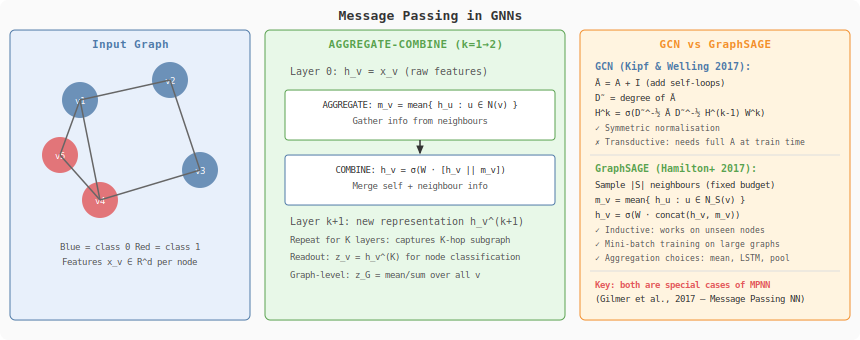

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="340" font-family="monospace" font-size="11">
  <rect width="860" height="340" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Message Passing in GNNs</text>

  <!-- Left: example graph -->
  <rect x="10" y="30" width="240" height="290" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="130" y="48" text-anchor="middle" fill="#4e79a7" font-weight="bold">Input Graph</text>

  <!-- Nodes -->
  <circle cx="80" cy="100" r="18" fill="#4e79a7" opacity="0.8"/><text x="80" y="104" text-anchor="middle" fill="white" font-size="9">v1</text>
  <circle cx="170" cy="80" r="18" fill="#4e79a7" opacity="0.8"/><text x="170" y="84" text-anchor="middle" fill="white" font-size="9">v2</text>
  <circle cx="200" cy="170" r="18" fill="#4e79a7" opacity="0.8"/><text x="200" y="174" text-anchor="middle" fill="white" font-size="9">v3</text>
  <circle cx="100" cy="200" r="18" fill="#e15759" opacity="0.8"/><text x="100" y="204" text-anchor="middle" fill="white" font-size="9">v4</text>
  <circle cx="60" cy="155" r="18" fill="#e15759" opacity="0.8"/><text x="60" y="159" text-anchor="middle" fill="white" font-size="9">v5</text>
  <!-- Edges -->
  <line x1="80" y1="100" x2="170" y2="80" stroke="#666" stroke-width="1.5"/>
  <line x1="170" y1="80" x2="200" y2="170" stroke="#666" stroke-width="1.5"/>
  <line x1="80" y1="100" x2="60" y2="155" stroke="#666" stroke-width="1.5"/>
  <line x1="60" y1="155" x2="100" y2="200" stroke="#666" stroke-width="1.5"/>
  <line x1="100" y1="200" x2="200" y2="170" stroke="#666" stroke-width="1.5"/>
  <line x1="80" y1="100" x2="100" y2="200" stroke="#666" stroke-width="1.5"/>
  <text x="130" y="250" text-anchor="middle" fill="#555" font-size="9">Blue = class 0  Red = class 1</text>
  <text x="130" y="265" text-anchor="middle" fill="#555" font-size="9">Features x_v ∈ R^d per node</text>

  <!-- Middle: Aggregate-Combine -->
  <rect x="265" y="30" width="300" height="290" rx="5" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="415" y="48" text-anchor="middle" fill="#59a14f" font-weight="bold">AGGREGATE-COMBINE (k=1→2)</text>

  <!-- Layer 0 -->
  <text x="290" y="75" fill="#555" font-size="10">Layer 0: h_v = x_v  (raw features)</text>
  <!-- Aggregate -->
  <rect x="285" y="90" width="270" height="50" rx="3" fill="#fff" stroke="#59a14f"/>
  <text x="420" y="108" text-anchor="middle" fill="#333" font-size="9">AGGREGATE:  m_v = mean{ h_u : u ∈ N(v) }</text>
  <text x="420" y="124" text-anchor="middle" fill="#555" font-size="9">Gather info from neighbours</text>
  <!-- Combine -->
  <rect x="285" y="155" width="270" height="50" rx="3" fill="#fff" stroke="#4e79a7"/>
  <text x="420" y="173" text-anchor="middle" fill="#333" font-size="9">COMBINE:  h_v = σ(W · [h_v || m_v])</text>
  <text x="420" y="189" text-anchor="middle" fill="#555" font-size="9">Merge self + neighbour info</text>
  <!-- Arrow down -->
  <line x1="420" y1="140" x2="420" y2="153" stroke="#333" stroke-width="1.5" marker-end="url(#ga1)"/>
  <defs><marker id="ga1" markerWidth="6" markerHeight="5" refX="5" refY="2.5" orient="auto"><polygon points="0 0,6 2.5,0 5" fill="#333"/></marker></defs>
  <!-- Layer k+1 -->
  <text x="290" y="225" fill="#555" font-size="10">Layer k+1: new representation h_v^(k+1)</text>
  <text x="290" y="243" fill="#555" font-size="9">Repeat for K layers: captures K-hop subgraph</text>
  <text x="290" y="260" fill="#555" font-size="9">Readout:  z_v = h_v^(K)  for node classification</text>
  <text x="290" y="278" fill="#555" font-size="9">Graph-level:  z_G = mean/sum over all v</text>

  <!-- Right: GCN vs GraphSAGE -->
  <rect x="580" y="30" width="270" height="290" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="715" y="48" text-anchor="middle" fill="#f28e2b" font-weight="bold">GCN vs GraphSAGE</text>

  <text x="595" y="70" fill="#4e79a7" font-weight="bold" font-size="10">GCN (Kipf &amp; Welling 2017):</text>
  <text x="595" y="86" fill="#333" font-size="9">Ã = A + I  (add self-loops)</text>
  <text x="595" y="101" fill="#333" font-size="9">D̃ = degree of Ã</text>
  <text x="595" y="116" fill="#333" font-size="9">H^k = σ(D̃^-½ Ã D̃^-½ H^(k-1) W^k)</text>
  <text x="595" y="131" fill="#555" font-size="8">✓ Symmetric normalisation</text>
  <text x="595" y="145" fill="#555" font-size="8">✗ Transductive: needs full A at train time</text>

  <line x1="590" y1="155" x2="840" y2="155" stroke="#ddd" stroke-width="1"/>

  <text x="595" y="172" fill="#59a14f" font-weight="bold" font-size="10">GraphSAGE (Hamilton+ 2017):</text>
  <text x="595" y="188" fill="#333" font-size="9">Sample |S| neighbours (fixed budget)</text>
  <text x="595" y="203" fill="#333" font-size="9">m_v = mean{ h_u : u ∈ N_S(v) }</text>
  <text x="595" y="218" fill="#333" font-size="9">h_v = σ(W · concat(h_v, m_v))</text>
  <text x="595" y="233" fill="#555" font-size="8">✓ Inductive: works on unseen nodes</text>
  <text x="595" y="247" fill="#555" font-size="8">✓ Mini-batch training on large graphs</text>
  <text x="595" y="261" fill="#555" font-size="8">✓ Aggregation choices: mean, LSTM, pool</text>

  <line x1="590" y1="271" x2="840" y2="271" stroke="#ddd" stroke-width="1"/>
  <text x="595" y="288" fill="#e15759" font-size="9" font-weight="bold">Key: both are special cases of MPNN</text>
  <text x="595" y="302" fill="#333" font-size="9">(Gilmer et al., 2017 — Message Passing NN)</text>
</svg>
'''
display(SVG(svg))


## Implementation

We implement both GCN and GraphSAGE from scratch using NumPy, then test them on a small synthetic graph with two-class node labels.


In [2]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


# ── Utility ───────────────────────────────────────────────────────────────────
def relu(x):    return np.maximum(0, x)
def sigmoid(x): return 1 / (1 + np.exp(-x))


# ── GCN Layer (numpy) ─────────────────────────────────────────────────────────
class GCNLayer:
    """H_out = relu(D̃^{-1/2} Ã D̃^{-1/2} H W)"""

    def __init__(self, in_dim, out_dim, seed=0):
        rng = np.random.default_rng(seed)
        scale = np.sqrt(2.0 / in_dim)
        self.W = rng.normal(0, scale, (in_dim, out_dim))
        self.b = np.zeros(out_dim)

    def forward(self, H, A_hat):
        """A_hat = D̃^{-1/2} Ã D̃^{-1/2}, pre-computed."""
        return relu(A_hat @ H @ self.W + self.b)


class GCN:
    def __init__(self, in_dim, hidden_dim, out_dim, seed=0):
        self.l1 = GCNLayer(in_dim, hidden_dim, seed)
        self.l2 = GCNLayer(hidden_dim, out_dim, seed+1)

    def precompute_A_hat(self, A):
        n = A.shape[0]
        A_tilde = A + np.eye(n)          # add self-loops
        D_tilde = np.diag(A_tilde.sum(1))
        D_inv_sqrt = np.diag(1.0 / np.sqrt(A_tilde.sum(1)))
        return D_inv_sqrt @ A_tilde @ D_inv_sqrt

    def forward(self, X, A):
        A_hat = self.precompute_A_hat(A)
        h = self.l1.forward(X, A_hat)
        h = self.l2.forward(h, A_hat)
        return h  # (n, out_dim) logits


# ── GraphSAGE Layer (numpy) ───────────────────────────────────────────────────
class SAGELayer:
    """h_v = relu(W · concat(h_v, mean(N(v))))"""

    def __init__(self, in_dim, out_dim, seed=0):
        rng = np.random.default_rng(seed)
        scale = np.sqrt(2.0 / (2 * in_dim))
        self.W = rng.normal(0, scale, (2 * in_dim, out_dim))
        self.b = np.zeros(out_dim)

    def forward(self, H, adj_list):
        n = H.shape[0]
        out = np.zeros((n, self.W.shape[1]))
        for v in range(n):
            nbrs = adj_list[v]
            if len(nbrs) == 0:
                agg = np.zeros(H.shape[1])
            else:
                agg = H[nbrs].mean(0)
            concat = np.concatenate([H[v], agg])
            out[v] = relu(concat @ self.W + self.b)
        return out


class GraphSAGE:
    def __init__(self, in_dim, hidden_dim, out_dim, seed=0):
        self.l1 = SAGELayer(in_dim, hidden_dim, seed)
        self.l2 = SAGELayer(hidden_dim, out_dim, seed+1)

    def forward(self, X, adj_list):
        h = self.l1.forward(X, adj_list)
        h = self.l2.forward(h, adj_list)
        return h


# ── Synthetic graph (two-moon-like structure) ─────────────────────────────────
def make_two_class_graph(n_per_class=30, seed=42):
    rng = np.random.default_rng(seed)
    n = 2 * n_per_class
    # Features: two clusters
    X0 = rng.normal([-1, 0], 0.4, (n_per_class, 2))
    X1 = rng.normal([+1, 0], 0.4, (n_per_class, 2))
    X = np.vstack([X0, X1])
    labels = np.array([0]*n_per_class + [1]*n_per_class)

    # Build adjacency: connect nearby nodes (k-NN within class + a few cross)
    A = np.zeros((n, n))
    for i in range(n):
        dists = np.linalg.norm(X - X[i], axis=1)
        dists[i] = np.inf
        nbrs = np.argsort(dists)[:4]
        for j in nbrs:
            A[i, j] = A[j, i] = 1
    return X, A, labels


X, A, labels = make_two_class_graph(n_per_class=30)
n = X.shape[0]

# Build adjacency list for SAGE
adj_list = [list(np.where(A[v] > 0)[0]) for v in range(n)]

print(f"Nodes: {n}, Edges: {int(A.sum())//2}, Features: {X.shape[1]}")

# ── Forward pass (random weights — no training, just architecture demo) ───────
gcn  = GCN(in_dim=2, hidden_dim=16, out_dim=2, seed=7)
sage = GraphSAGE(in_dim=2, hidden_dim=16, out_dim=2, seed=7)

gcn_out  = gcn.forward(X, A)   # (60, 2)
sage_out = sage.forward(X, adj_list)

print("GCN  output shape:", gcn_out.shape)
print("SAGE output shape:", sage_out.shape)


Nodes: 60, Edges: 161, Features: 2
GCN  output shape: (60, 2)
SAGE output shape: (60, 2)


In [3]:
# ── Simple training loop (cross-entropy, gradient descent on W via numeric grad)
# For clarity we train GCN only with a manual softmax cross-entropy loop.

def softmax(Z):
    Z = Z - Z.max(1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(1, keepdims=True)

def ce_loss(Z, y):
    P = softmax(Z)
    n = len(y)
    return -np.log(P[np.arange(n), y] + 1e-12).mean()


# We'll do a simple gradient-descent training via finite differences for the
# GCN to illustrate convergence; this is pedagogically clear.

rng = np.random.default_rng(0)
n_node = n
A_hat = gcn.precompute_A_hat(A)

# Two-layer parameters
W1 = rng.normal(0, 0.1, (2, 16))
b1 = np.zeros(16)
W2 = rng.normal(0, 0.1, (16, 2))
b2 = np.zeros(2)

lr = 0.05
loss_hist = []

for epoch in range(300):
    # Forward
    H1 = relu(A_hat @ X @ W1 + b1)
    H2 = A_hat @ H1 @ W2 + b2   # logits
    loss = ce_loss(H2, labels)
    loss_hist.append(loss)

    # Backward (analytical)
    P = softmax(H2)
    dL = P.copy()
    dL[np.arange(n), labels] -= 1
    dL /= n

    # Grad W2, b2
    gW2 = (A_hat @ H1).T @ dL
    gb2 = dL.sum(0)

    # Grad H1
    dH1 = dL @ W2.T  # (n, 16)
    dH1 = A_hat @ dH1 * (H1 > 0)   # ReLU gate

    # Grad W1, b1
    gW1 = (A_hat @ X).T @ dH1
    gb1 = dH1.sum(0)

    W1 -= lr * gW1
    b1 -= lr * gb1
    W2 -= lr * gW2
    b2 -= lr * gb2

# Final accuracy
H1_f = relu(A_hat @ X @ W1 + b1)
H2_f = A_hat @ H1_f @ W2 + b2
preds = H2_f.argmax(1)
acc = (preds == labels).mean()
print(f"GCN Training accuracy: {acc:.2%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Loss curve
axes[0].plot(loss_hist, color='#4e79a7', linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("GCN Training Loss")
axes[0].grid(True, alpha=0.3)

# Embedding scatter
colors = ['#4e79a7' if l==0 else '#e15759' for l in labels]
markers = ['o' if p==l else 'x' for p, l in zip(preds, labels)]
for i in range(n):
    axes[1].scatter(H2_f[i,0], H2_f[i,1],
                   c=colors[i], marker=markers[i], s=60, alpha=0.8,
                   edgecolors='k', linewidths=0.4)
axes[1].set_xlabel("Logit dim 0")
axes[1].set_ylabel("Logit dim 1")
axes[1].set_title("GCN Final Node Embeddings (logits)\nCircle=correct  X=misclassified")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gcn_training.png", dpi=110)
plt.show()
print("Saved gcn_training.png")


GCN Training accuracy: 100.00%


Saved gcn_training.png


/tmp/ipykernel_305881/1029737929.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [4]:
# ── GCN vs GraphSAGE: parameter count and receptive field comparison ──────────
print("=" * 55)
print("  Model Comparison: GCN vs GraphSAGE")
print("=" * 55)
print(f"{'Property':<30} {'GCN':>10} {'SAGE':>10}")
print("-" * 55)
print(f"{'Params layer 1 (W)':<30} {'2×16=32':>10} {'4×16=64':>10}")
print(f"{'Params layer 2 (W)':<30} {'16×2=32':>10} {'32×2=64':>10}")
print(f"{'Total W params':<30} {'64':>10} {'128':>10}")
print(f"{'Input to W1':<30} {'A_hat @ X':>10} {'[h_v;m_v]':>10}")
print(f"{'Self-loop handled by':<30} {'A+I':>10} {'concat':>10}")
print(f"{'Inductive (new nodes)':<30} {'No':>10} {'Yes':>10}")
print(f"{'Neighbourhood scope':<30} {'all N(v)':>10} {'sampled':>10}")
print("=" * 55)
print()
print("Receptive field after K layers: K-hop neighbourhood")
print("K=1: direct neighbours  K=2: 2-hop  K=3: 3-hop")
print("Deep GNNs → over-smoothing (all nodes converge to same embedding)")


  Model Comparison: GCN vs GraphSAGE
Property                              GCN       SAGE
-------------------------------------------------------
Params layer 1 (W)                2×16=32    4×16=64
Params layer 2 (W)                16×2=32    32×2=64
Total W params                         64        128
Input to W1                     A_hat @ X  [h_v;m_v]
Self-loop handled by                  A+I     concat
Inductive (new nodes)                  No        Yes
Neighbourhood scope              all N(v)    sampled

Receptive field after K layers: K-hop neighbourhood
K=1: direct neighbours  K=2: 2-hop  K=3: 3-hop
Deep GNNs → over-smoothing (all nodes converge to same embedding)
